# Исследование объявлений о продаже квартир

Данные сервиса Яндекс.Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктов за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Задача — установить параметры. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность. 

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта, ближайшего парка и водоёма. 

In [1]:
import pandas as pd

pd.options.display.float_format = '{:,.1f}'.format

import matplotlib.pyplot as plt

df = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [2]:
# Рассмотрим первые 10 строк из таблицы

df.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,"13,000,000.0",108.0,2019-03-07T00:00:00,3,2.7,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,"18,863.0","16,028.0",1.0,482.0,2.0,755.0,NaN
1,7,"3,350,000.0",40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,"12,817.0","18,603.0",0.0,NaN,0.0,NaN,81.0
2,10,"5,196,000.0",56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,"21,741.0","13,933.0",1.0,90.0,2.0,574.0,558.0
3,0,"64,900,000.0",159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,"28,098.0","6,800.0",2.0,84.0,3.0,234.0,424.0
4,2,"10,000,000.0",100.0,2018-06-19T00:00:00,2,3.0,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,"31,856.0","8,098.0",2.0,112.0,1.0,48.0,121.0
5,10,"2,890,000.0",30.4,2018-09-10T00:00:00,1,NaN,12.0,14.4,5,NaN,...,9.1,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,"3,700,000.0",37.3,2017-11-02T00:00:00,1,NaN,26.0,10.6,6,NaN,...,14.4,1.0,посёлок Парголово,"52,996.0","19,143.0",0.0,NaN,0.0,NaN,155.0
7,5,"7,915,000.0",71.6,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.9,2.0,Санкт-Петербург,"23,982.0","11,634.0",0.0,NaN,0.0,NaN,NaN
8,20,"2,900,000.0",33.2,2018-05-23T00:00:00,1,NaN,27.0,15.4,26,NaN,...,8.8,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,"5,400,000.0",61.0,2017-02-26T00:00:00,3,2.5,9.0,43.6,7,NaN,...,6.5,2.0,Санкт-Петербург,"50,898.0","15,008.0",0.0,NaN,0.0,NaN,289.0


In [3]:
# Рассмотрим вычисления описательной статистики по данным в датафрейме

df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_images,"23,699.0",9.9,5.7,0.0,6.0,9.0,14.0,50.0
last_price,"23,699.0","6,541,548.8","10,887,013.3","12,190.0","3,400,000.0","4,650,000.0","6,800,000.0","763,000,000.0"
total_area,"23,699.0",60.3,35.7,12.0,40.0,52.0,69.9,900.0
rooms,"23,699.0",2.1,1.1,0.0,1.0,2.0,3.0,19.0
ceiling_height,"14,504.0",2.8,1.3,1.0,2.5,2.6,2.8,100.0
floors_total,"23,613.0",10.7,6.6,1.0,5.0,9.0,16.0,60.0
living_area,"21,796.0",34.5,22.0,2.0,18.6,30.0,42.3,409.7
floor,"23,699.0",5.9,4.9,1.0,2.0,4.0,8.0,33.0
kitchen_area,"21,421.0",10.6,5.9,1.3,7.0,9.1,12.0,112.0
balcony,"12,180.0",1.2,1.1,0.0,0.0,1.0,2.0,5.0


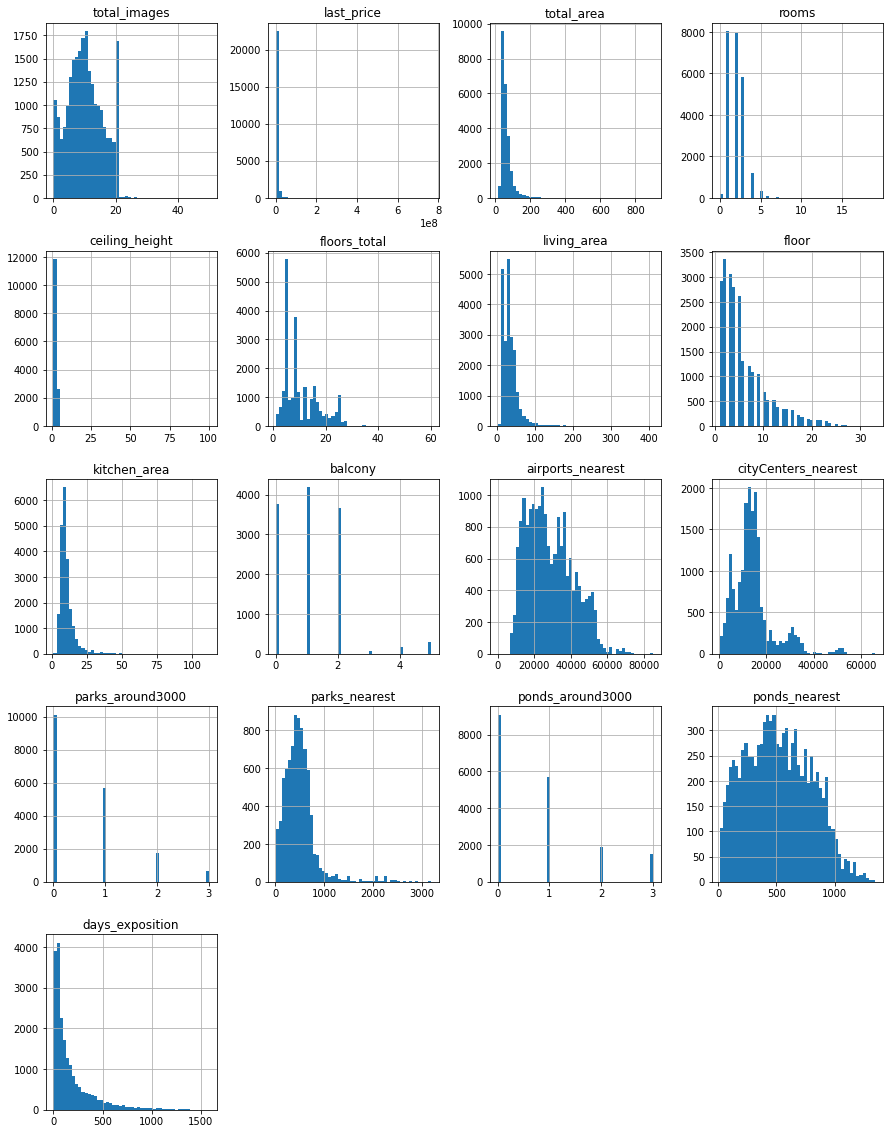

In [4]:
df.hist(bins=50,figsize=(15, 20));

**Вывод:**\
Мы вывели на экран основную информацию о предложенном для исследования датафрейме. Данные необходимо предобработать для дальнейшего изучения, так как:
- Не все названия столбцов стандартизированы, необходимо привести к стандартному виду.
- Не все столбцы имеют подходящий тип данных, необходимо это исправить.
- В данных присутствуют выбросы, необходимо выяснить, почему они появились и как с ними работать (например, высота потолков 100 м)
    

### Предобработка данных

In [5]:
# Переименовываем столбцы, которые не подходят под snake_case
df = df.rename(columns={'cityCenters_nearest':'city_centers_nearest', 
                            'parks_around3000': 'parks_around_3000', 
                            'ponds_around3000': 'ponds_around_3000'})

#### Обработка пропусков

In [6]:
# Посмотрим на количество пропусков

df_null = df.isna()
df_null.apply(['sum', 'mean']).transpose().sort_values(by='mean', ascending=False).style.format('{:.3f}')

,sum,mean
is_apartment,20924.000,0.883
parks_nearest,15620.000,0.659
ponds_nearest,14589.000,0.616
balcony,11519.000,0.486
ceiling_height,9195.000,0.388
airports_nearest,5542.000,0.234
city_centers_nearest,5519.000,0.233
ponds_around_3000,5518.000,0.233
parks_around_3000,5518.000,0.233
days_exposition,3181.000,0.134


*Обнаруженные пропуски в столбцах и способы заполнения этих пропусков:*\
\
**is_apartment** - апартаменты (булев тип), пропуск скорее всего обозначает, что квартира не является апартаментами, заполним пропуски значением "False", а также изменим тип данных на bool, в данном столбце больше всего пропусков: 88.3%;\
**ceiling_height** - высота потолков, пропусков много, 38.8%, заполним их средним значением, данное значение скорее всего будет в диапозоне 2.5-2.7 м;\
**balcony** - наличие балкона, 48.6% пропусков - заполним пропуски 0, тк если графа пустует, скорее всего балкона нет, изменим тип данных столбца на int;\
**floors_total** - всего этажей в доме, скорее всего ручная ошибка пользователей (не помнят сколько этажей, забыли заполнить и пр.), пропусков немного, оставим пустыми;\
**living_area** - жилая площадь, как и с этажами, скорее всего ошибка пользователей (не знают площадь и пр.), пропусков не так много, но они важны, заполним их медианным значением с учетом соотношения площадей;\
**kitchen_area** - площадь кухни, ошибка пользователя, пропусков немного, заполним их медианным значением с учетом соотношения площадей;\
**locality_name** - название насленного пункта, пропусков немного, заполним их обозначением 'не указан';\
\
Ниже представлены столбцы с пропусками, данные в которых заполняются без участия пользователей. Скорее всего, при выгрузке данных была допушена техническая ошибка. Многие из этих данных необходимы, но нам нечем заполнить пропуски, оставим их пустыми.
\
\
**airports_nearest** - расстояние до ближайшего аэропорта;\
**city_centers_nearest** - близость к центру;\
**parks_around_3000** - число парков в радиусе 3 км;\
**parks_nearest** - расстояние до ближайшего парка;\
**ponds_around_3000** - число водоемов в радиусе 3 км;\
**ponds_nearest** - расстояние до ближайшего водоема;\
**days_exposition** - сколько дней было размещено объявление.

In [7]:
# Заполним пропуски в столбце ceiling_height

df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].mean())

In [8]:
# Заполним пропуски в столбце living_area 

df['living_area'] = df['living_area'].fillna(df['total_area'] * (df['living_area'] / df['total_area']).median())


In [9]:
# Заполним пропуски в столбце kitchen_area

df['kitchen_area'] = df['kitchen_area'].fillna(df['total_area'] * (df['kitchen_area'] / df['total_area']).median())

In [10]:
# Заполним пропуске в столбце is_apartment

df['is_apartment'] = df['is_apartment'].fillna(False).astype('bool')

In [11]:
# Заполним пропуски в столбце balcony

df['balcony'] = df['balcony'].fillna(0).astype('int')

In [12]:
# Заполним пропуски в столбце locality_name

df['locality_name'] = df['locality_name'].fillna('не указан')

#### Изменение типов данных

Ранее мы уже изменили тип данных в столбцах **is_apartment** и **balcony**, осталось еще столбец, в котором необходимо это сделать:\
\
**first_day_exposition** - дата публикации, необходим тип данных datetime

In [13]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'])

In [14]:
# Проверим, что все изменения применены

df.info()

df.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           23699 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          23699 non-null  float64       
 13  balcony         

parks_nearest           15620
ponds_nearest           14589
airports_nearest         5542
city_centers_nearest     5519
ponds_around_3000        5518
parks_around_3000        5518
days_exposition          3181
floors_total               86
kitchen_area                0
locality_name               0
balcony                     0
total_images                0
last_price                  0
studio                      0
is_apartment                0
floor                       0
living_area                 0
ceiling_height              0
rooms                       0
first_day_exposition        0
total_area                  0
open_plan                   0
dtype: int64

#### Устранение неявных дубликатов

In [15]:
df.duplicated().sum()

0

Явных дубликатов в датасете не обнаружено. Обработаем неявные дубликаты, они могут возникнуть в столбце **locality_name**.

In [16]:
df['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Необходимо заменить всю букву ё на букву е, а также привести названия населенных пунктов к единому стилю.

In [17]:
df['locality_name'] = df['locality_name'].str.replace('ё', 'е')

df['locality_name'] = df['locality_name'].str.replace(
    r'поселок городского типа|городской поселок|поселок при железнодорожной станции', 
    'поселок', regex=True
)

df['locality_name'] = df['locality_name'].replace(
    {'Шушары': 'поселок Шушары', 'Мурино': 'поселок Мурино', 
     'деревня Кудрово': 'Кудрово', 'поселок Любань': 'Любань'}
)


In [18]:
# Проверим изменения
df['locality_name'].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'Кудрово', 'Коммунар', 'Колпино',
       'поселок Красный Бор', 'Гатчина', 'деревня Федоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'деревня Новое Девяткино',
       'поселок Металлострой', 'поселок Лебяжье', 'поселок Сиверский',
       'поселок Молодцово', 'поселок Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'поселок Аннино',
       'поселок Ефимовский', 'поселок Плодовое', 'деревня Заклинье',
       'поселок Торковичи', 'поселок Первомайское', 'Красное Село',
       'поселок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'поселок Новый Свет', 'Сланцы',
       'село Путилово', 'Ивангород', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый 

Данные приведены к единому виду.

#### Устранение аномальных значений

В датасете есть выбросы, необходимо от них избавиться, для того чтобы показатели в нашем исследовании были точнее:\
\
**last_price** max=763000000: большая цена, вероятно, элитная историческая недвижимость. Не смотря на то, что такая цена действительно может существовать, лучше исключить ее из исследования, так как такой случай уникален. Также удалим min=12190: таких маленьких цен на недвижимость, к сожалению, не бывает.\
\
**rooms** max=19, min=0: на первый взгляд могут показаться выбросами, но стоит уточнить у специалистов Яндекс.Недвижимость причины (0 комнат может оказаться нежилым помещением, а 19 комнат - все той же элитной недвижимостью). Эти данные оставляем.\
\
**ceiling_height** max=100, min=1: Средняя высота потолков в жилых помещениях - примерно 2.5 метра. С минимальным значением скорее всего допущена ошибка, удалим его. Так же поступим и с максимальным значением. Проверим также остальные значения, если среди них будут значения больше 20м, вероятно пользователем была допущена ошибка в запятой, разделим эти значения на 10.\
\
**balcony** max=5: также аномальное значение, удалим его из исследования.\
\
**total_area** max=900: слишком большая площадь недвижимости, чтобы избежать выбросов, удалим его из исследования.


In [19]:
# Удалим из датафрейма значения меньше 2м

df = df[df['ceiling_height'] >= 2]

# При высоте потолков более 20м будем делить значение на 10

df.loc[df['ceiling_height'] >= 20, 'ceiling_height'] = df['ceiling_height'] / 10

# Посмотрим на значения среднего и медианы

print('Среднее:', df['ceiling_height'].mean().round(2))
print('Медиана:', df['ceiling_height'].median())


Среднее: 2.75
Медиана: 2.77149889685604


In [20]:
# Уберем аномальные значения из столбца last_price

df = df[(df['last_price'] > 12190) & (df['last_price'] < 763000000)]

In [21]:
# Уберем аномальное значение из столбца balcony

df = df[df['balcony'] < 5]

In [22]:
 # Проверим, что все аномалии устранены
    
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_images,"23,390.0",9.8,5.7,0.0,6.0,9.0,14.0,50.0
last_price,"23,390.0","6,479,889.3","9,723,659.5","430,000.0","3,400,000.0","4,600,000.0","6,700,000.0","420,000,000.0"
total_area,"23,390.0",60.1,35.5,12.0,40.0,51.8,69.0,900.0
rooms,"23,390.0",2.1,1.1,0.0,1.0,2.0,3.0,19.0
ceiling_height,"23,390.0",2.7,0.2,2.0,2.6,2.8,2.8,14.0
floors_total,"23,304.0",10.6,6.6,1.0,5.0,9.0,16.0,60.0
living_area,"23,390.0",34.4,22.3,2.0,19.0,30.0,42.0,409.7
floor,"23,390.0",5.9,4.9,1.0,2.0,4.0,8.0,33.0
kitchen_area,"23,390.0",10.5,6.0,1.3,7.0,9.0,11.9,112.0
balcony,"23,390.0",0.5,0.8,0.0,0.0,0.0,1.0,4.0


In [23]:
df_cleaned = df
df_original = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
removed_percentage = (1 - len(df_cleaned) / len(df_original)) * 100
print(f'Процент удаленных данных: {removed_percentage:.2f}%')


Процент удаленных данных: 1.30%


Предобработка данных завершена: приведены к стандартному виду названия столбцов; по возможности заполнены пропуски, изменены типы данных у нескольких столбцов для удобства работы с данными; устранены неявные дубликаты и проанализированы аномальные значения. Все готово для дальнейшего исследования.

### Посчитайте и добавьте в таблицу новые столбцы

Для дальнейшего анализа нам необходимо создать новые столбцы:
- цена одного квадратного метра **sq_meter_price**;
- день недели публикации объявления **weekday_exp** (0 — понедельник, 1 — вторник и т.д.);
- месяц публикации объявления **month_exp**;
- год публикации объявления **year_exp**;
- тип этажа квартиры **floor_type**(значения «первый», «последний», «другой»);
- расстояние до центра города в километрах **city_centers_nearest_km**.

In [24]:
# Создаем столбец с ценой одного квадратного метра, для удобства округлим значения до второго знака после запятой

df['sq_meter_price'] = (df['last_price'] / df['total_area']).round(2)

In [25]:
# Создаем столбцы отдельные столбцы с днем недели, месяцем и годом

df['weekday_exp'] = df['first_day_exposition'].dt.weekday.astype('category')

df['month_exp'] = df['first_day_exposition'].dt.month.astype('category')

df['year_exp'] = df['first_day_exposition'].dt.year.astype('category')



In [26]:
# Создаем столбец с расстоянием до центра города в километрах
# Первоначальные данные представлены в метрах, поэтому необходимо привести их к километрам и округлить

df['city_centers_nearest_km'] = (df['city_centers_nearest'] / 1000).round()


In [27]:
# Функция для категоризации этажей, которая возвращает тип этажа: первый, последний или другой

def floor_type(row):
    try:
        floor = row['floor']
        floors_total = row['floors_total']
        if floor == 1:
            return 'первый'
        elif floor == floors_total:
            return 'последний'
        elif floor <= floors_total:
            return 'другой'
    except:
        pass
    
# Создаем новый столбец с категорией этажа
    
df['floor_type'] = df.apply(floor_type, axis=1) 
df['floor_type'] = df['floor_type'].astype('category')

In [28]:
# Проверим, что новые столбцы появились в исходном датасете

df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,sq_meter_price,weekday_exp,month_exp,year_exp,city_centers_nearest_km,floor_type
0,20,"13,000,000.0",108.0,2019-03-07,3,2.7,16.0,51.0,8,False,...,482.0,2.0,755.0,NaN,"120,370.4",3,3,2019,16.0,другой
1,7,"3,350,000.0",40.4,2018-12-04,1,2.8,11.0,18.6,1,False,...,NaN,0.0,NaN,81.0,"82,920.8",1,12,2018,19.0,первый
2,10,"5,196,000.0",56.0,2015-08-20,2,2.8,5.0,34.3,4,False,...,90.0,2.0,574.0,558.0,"92,785.7",3,8,2015,14.0,другой
3,0,"64,900,000.0",159.0,2015-07-24,3,2.8,14.0,90.3,9,False,...,84.0,3.0,234.0,424.0,"408,176.1",4,7,2015,7.0,другой
4,2,"10,000,000.0",100.0,2018-06-19,2,3.0,14.0,32.0,13,False,...,112.0,1.0,48.0,121.0,"100,000.0",1,6,2018,8.0,другой


Новые данные появились в исходном датасете, можем приступать к исследовательскому анализу данных.

### Проведите исследовательский анализ данных

Необходимо изучить следующие параметры:
  - общая площадь;
  - жилая площадь;
  - площадь кухни;
  - цена объекта;
  - количество комнат;
  - высота потолков;
  - этаж квартиры;
  - тип этажа квартиры («первый», «последний», «другой»);
  - общее количество этажей в доме;
  - расстояние до центра города в метрах;
  - расстояние до ближайшего аэропорта;
  - расстояние до ближайшего парка;
  - день и месяц публикации объявления.\
\
Построим гистограммы для каждого параметра и на их основе сделаем выводы о предложенных данных.


**Столбец total_area - общая площадь**


Text(0, 0.5, 'Частота')

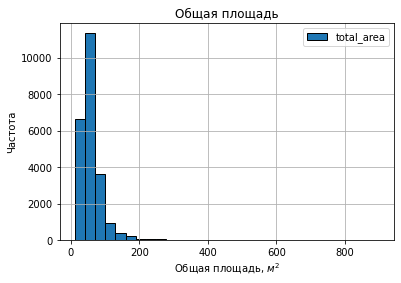

In [29]:
df.plot(y='total_area', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Общая площадь')
plt.xlabel('Общая площадь, $м^{2}$')
plt.ylabel('Частота')



In [30]:
df['total_area'].describe()

count   23,390.0
mean        60.1
std         35.5
min         12.0
25%         40.0
50%         51.8
75%         69.0
max        900.0
Name: total_area, dtype: float64

На гистограмме видны очень большие значения. Это могут быть, например, объекты с большой площадью, как мы уже выясняли при подготовке данных для анализа. Они могут существовать, однако, могут исказить результаты. Нам необходимо определить выбросы (с помощью IQR  - межквартильного размаха), а затем построить гистограмму без них.

In [31]:
# Создадим функцию для нахождения IQR

def iqr_limits(columns):
    q1 = df[columns].quantile(0.25)
    q3 = df[columns].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper
lower, upper = iqr_limits('total_area')

Text(0, 0.5, 'Частота')

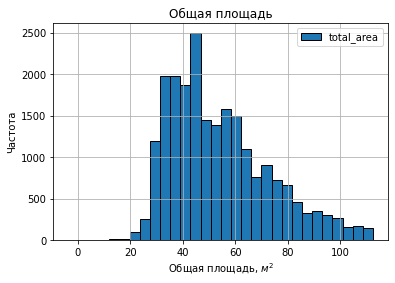

In [32]:
# Построим гистограмму без выбросов

df.plot(y='total_area', kind='hist', bins=30, range=(lower, upper), figsize=(6,4), ec='black', grid=True)
plt.title('Общая площадь')
plt.xlabel('Общая площадь, $м^{2}$')
plt.ylabel('Частота')


Вывод: Большинство квартир имеют общую площадь около 40 кв.м. Квартиры меньше 30 кв.м. и больше 100 кв.м. встречаются довольно редко.


**Столбец living_area - жилая площадь**

Text(0, 0.5, 'Частота')

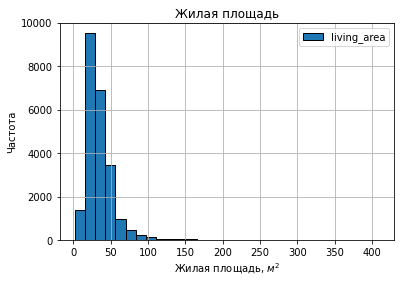

In [33]:
df.plot(y='living_area', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Жилая площадь')
plt.xlabel('Жилая площадь, $м^{2}$')
plt.ylabel('Частота')

In [34]:
df['living_area'].describe()

count   23,390.0
mean        34.4
std         22.3
min          2.0
25%         19.0
50%         30.0
75%         42.0
max        409.7
Name: living_area, dtype: float64

Так как данные схожие, поступаем по аналогии с столбцом total_area.

Text(0, 0.5, 'Частота')

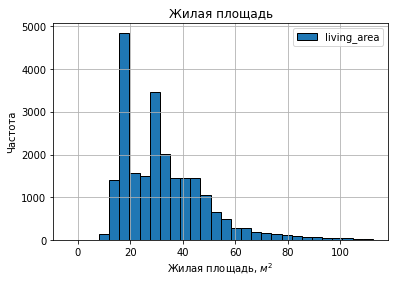

In [35]:
# Построим гистограмму без выбросов

iqr_limits('living_area')

df.plot(y='living_area', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Жилая площадь')
plt.xlabel('Жилая площадь, $м^{2}$')
plt.ylabel('Частота')

Вывод: Большинство квартир имеют жилую площадь около 19-30 кв.м. Квартиры с жилой площадью менее 10 кв.м., и более 50 кв.м. встречаются редко.


**Столбец kitchen_area - площадь кухни**

Text(0, 0.5, 'Частота')

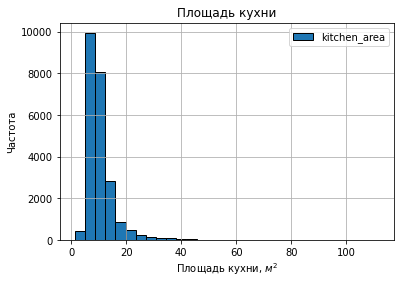

In [36]:
df.plot(y='kitchen_area', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Площадь кухни')
plt.xlabel('Площадь кухни, $м^{2}$')
plt.ylabel('Частота')

In [37]:
df['kitchen_area'].describe()

count   23,390.0
mean        10.5
std          6.0
min          1.3
25%          7.0
50%          9.0
75%         11.9
max        112.0
Name: kitchen_area, dtype: float64

Text(0, 0.5, 'Частота')

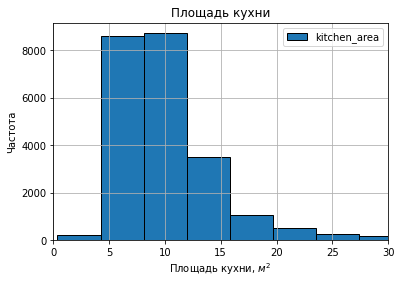

In [38]:
# Построим гистограмму без выбросов

iqr_limits('kitchen_area')

df.plot(y='kitchen_area', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Площадь кухни')
plt.xlabel('Площадь кухни, $м^{2}$')
plt.xlim(0, 30)
plt.ylabel('Частота')

Вывод: У большинства квартир в исследовании площадь кухни около 5-12 кв.м. Варианты с кухней меньше 4 кв.м. встречаются редко, как и варианты квартир с площадью более 20 кв.м.


**Столбец last_price - цена объекта**

Text(0, 0.5, 'Частота')

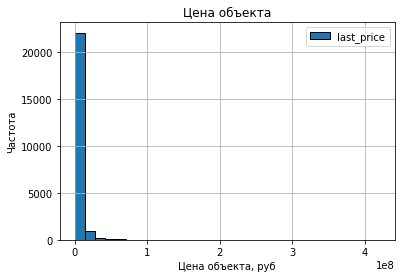

In [39]:
df.plot(y='last_price', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Цена объекта')
plt.xlabel('Цена объекта, руб')
plt.ylabel('Частота')

In [40]:
df['last_price'].describe()

count        23,390.0
mean      6,479,889.3
std       9,723,659.5
min         430,000.0
25%       3,400,000.0
50%       4,600,000.0
75%       6,700,000.0
max     420,000,000.0
Name: last_price, dtype: float64

Text(0, 0.5, 'Частота')

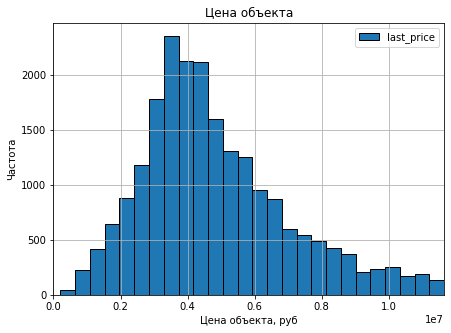

In [41]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('last_price')
df.plot(y='last_price', kind='hist', bins=30, range=(lower,upper), figsize=(7,5), ec='black', grid=True)
plt.title('Цена объекта')
plt.xlabel('Цена объекта, руб')
plt.xlim(0, upper)
plt.ylabel('Частота')

Вывод: Чаще всего встречаются объекты с ценой от 3 до 5 млн руб. Объекты дороже 7 млн руб. встречаются редко, как и объекты дешевле 2 млн.руб.


**Столбец rooms - число комнат**

Text(0, 0.5, 'Частота')

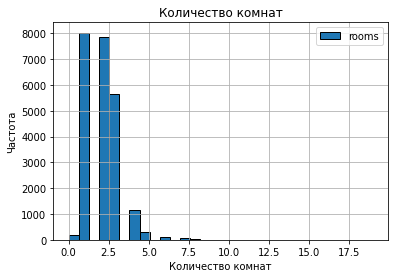

In [42]:
df.plot(y='rooms', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Количество комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Частота')

In [43]:
df['rooms'].describe()

count   23,390.0
mean         2.1
std          1.1
min          0.0
25%          1.0
50%          2.0
75%          3.0
max         19.0
Name: rooms, dtype: float64

Text(0, 0.5, 'Частота')

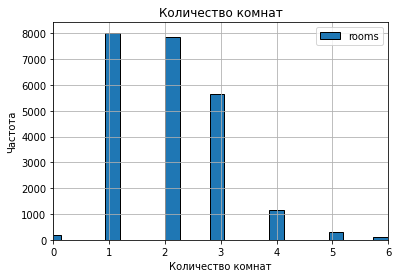

In [44]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('rooms')
df.plot(y='rooms', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Количество комнат')
plt.xlabel('Количество комнат')
plt.xlim(0, upper)
plt.ylabel('Частота')

Вывод: Большая часть объектов имеет 1-3 комнаты. Самый распространенный вариант - 2 комнаты. Квартиры с 4 комнатами и более встречаются реже.

**Столбец ceiling_height - высота потолков**

Text(0, 0.5, 'Частота')

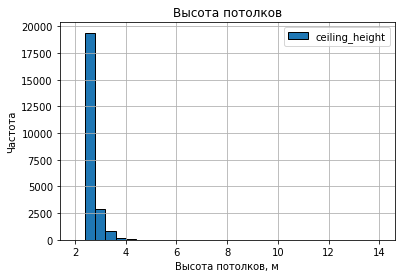

In [45]:
df.plot(y='ceiling_height', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Высота потолков')
plt.xlabel('Высота потолков, м')
plt.ylabel('Частота')

In [46]:
df['ceiling_height'].describe()

count   23,390.0
mean         2.7
std          0.2
min          2.0
25%          2.6
50%          2.8
75%          2.8
max         14.0
Name: ceiling_height, dtype: float64

Text(0, 0.5, 'Частота')

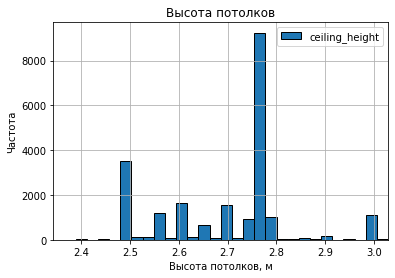

In [47]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('ceiling_height')
df.plot(y='ceiling_height', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Высота потолков')
plt.xlabel('Высота потолков, м')
plt.xlim(lower, upper)
plt.ylabel('Частота')

Вывод: Чаще всего встречаются квартиры с высотой потолков 2.5 м. Полоки с высотой более 2.7 м. и ниже 2.5 м. встречаются редко.


**Столбец floor - этаж**

Text(0, 0.5, 'Частота')

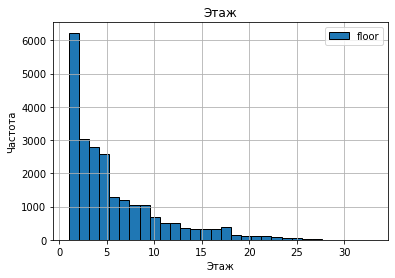

In [48]:
df.plot(y='floor', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Этаж')
plt.xlabel('Этаж')
plt.ylabel('Частота')

In [49]:
df['floor'].describe()

count   23,390.0
mean         5.9
std          4.9
min          1.0
25%          2.0
50%          4.0
75%          8.0
max         33.0
Name: floor, dtype: float64

Text(0, 0.5, 'Частота')

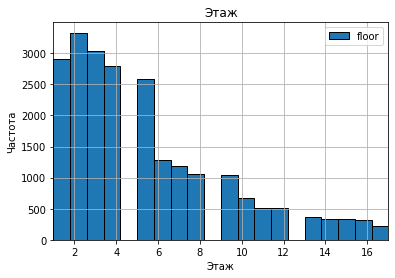

In [50]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('floor')

df.plot(y='floor', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Этаж')
plt.xlabel('Этаж')
plt.xlim(1, upper)
plt.ylabel('Частота')

Вывод: Чаще всего продают квартиры со 2 по 6 этаж. Квартиры этажами выше продаются реже.

Text(0.5, 1.0, 'Тип этажа квартиры')

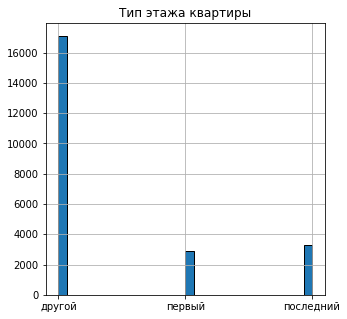

In [51]:
df['floor_type'].hist(bins=30, figsize=(5,5), ec='black')
plt.title('Тип этажа квартиры')

Вывод: Резултат довольно ожидаем, чаще всего продаются квартиры не на первом и последнем этажах. Количество продаваемых квартир на первом и последнем этажах примерно одинаково. Необходимости изучать выбросы в данном случае нет.


**Столбец floors_total - общее количество этажей в доме**

Text(0.5, 1.0, 'Количество этажей в доме')

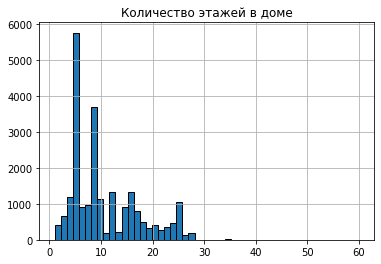

In [52]:
df['floors_total'].hist(bins=50, ec='black', figsize=(6,4))
plt.title('Количество этажей в доме')

In [53]:
df['floors_total'].describe()

count   23,304.0
mean        10.6
std          6.6
min          1.0
25%          5.0
50%          9.0
75%         16.0
max         60.0
Name: floors_total, dtype: float64

Text(0, 0.5, 'Частота')

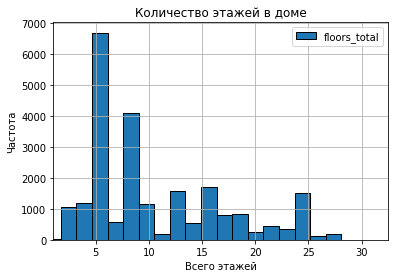

In [54]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('floors_total')

df.plot(y='floors_total', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Количество этажей в доме')
plt.xlabel('Всего этажей')
plt.xlim(1, upper)
plt.ylabel('Частота')

Вывод: Чаще всего продаются квартиры в домах с общей этажностью от 5 до 10 этажей. Реже всего продаются квартиры в домах с высотой более 18 этажей, что вполне логично, так как домов такой высоты не так много.


**Столбец city_centers_nearest - расстояние до центра города в метрах**

Text(0, 0.5, 'Частота')

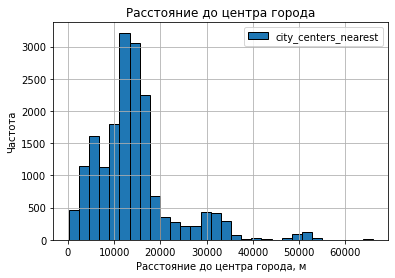

In [55]:
df.plot(y='city_centers_nearest', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Расстояние до центра города')
plt.xlabel('Расстояние до центра города, м')
plt.ylabel('Частота')

In [56]:
df['city_centers_nearest'].describe()

count   17,933.0
mean    14,178.7
std      8,629.8
min        181.0
25%      9,184.0
50%     13,087.0
75%     16,293.0
max     65,968.0
Name: city_centers_nearest, dtype: float64

Text(0, 0.5, 'Частота')

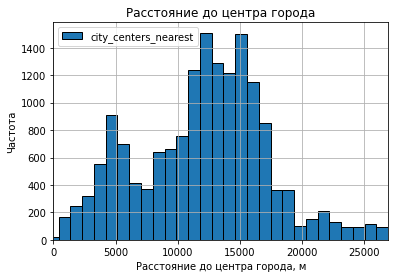

In [57]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('city_centers_nearest')

df.plot(y='city_centers_nearest', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Расстояние до центра города')
plt.xlabel('Расстояние до центра города, м')
plt.xlim(0, upper)
plt.ylabel('Частота')

Вывод: Чаще всего продаются квартиры в расстоянии 10-18 км от центра города. Самый распространенный вариант - около 14 км от центра. Предположительно, это недвижимость в спальных районах. Квартиры расположенные в 4 и менее км от города встречаются редко.

**Столбец airports_nearest - расстояние до аэропорта**

Text(0, 0.5, 'Частота')

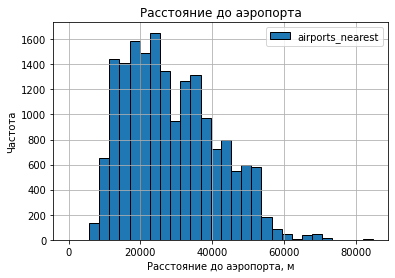

In [58]:
df.plot(y='airports_nearest', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Расстояние до аэропорта')
plt.xlabel('Расстояние до аэропорта, м')
plt.ylabel('Частота')

In [59]:
df['airports_nearest'].describe()

count   17,910.0
mean    28,761.6
std     12,627.8
min          0.0
25%     18,576.5
50%     26,646.0
75%     37,227.0
max     84,869.0
Name: airports_nearest, dtype: float64

Text(0, 0.5, 'Частота')

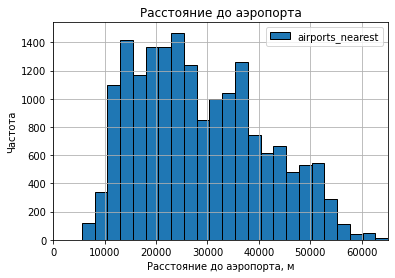

In [60]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('airports_nearest')

df.plot(y='airports_nearest', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Расстояние до аэропорта')
plt.xlabel('Расстояние до аэропорта, м')
plt.xlim(0, upper)
plt.ylabel('Частота')

Вывод: Среди представленных объявлений чаще всего встречается недвижимость на расстоянии 10-35 км до аэропорта. Практически не представлены объявления с квартирами в непосредственной близости от аэропорта.


**Столбец park_nearest - расстояние до ближайшего парка**

Text(0, 0.5, 'Частота')

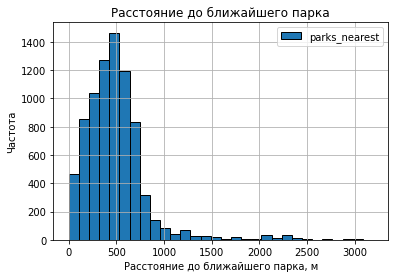

In [61]:
df.plot(y='parks_nearest', kind='hist', bins=30, figsize=(6,4), ec='black', grid=True)
plt.title('Расстояние до ближайшего парка')
plt.xlabel('Расстояние до ближайшего парка, м')
plt.ylabel('Частота')

In [62]:
df['parks_nearest'].describe()

count   7,973.0
mean      490.3
std       342.4
min         1.0
25%       287.0
50%       454.0
75%       612.0
max     3,190.0
Name: parks_nearest, dtype: float64

Text(0, 0.5, 'Частота')

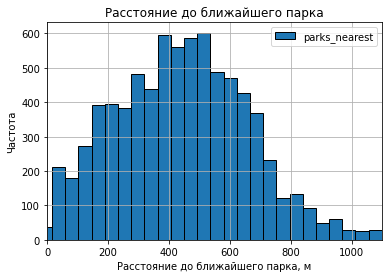

In [63]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('parks_nearest')

df.plot(y='parks_nearest', kind='hist', bins=30, range=(lower,upper), figsize=(6,4), ec='black', grid=True)
plt.title('Расстояние до ближайшего парка')
plt.xlabel('Расстояние до ближайшего парка, м')
plt.xlim(0, upper)
plt.ylabel('Частота')

Вывод: Чаще всего продается недвижимость с близостью парков от 180 до 600 м - широкие возможности для подбора недвижимости с местом для прогулок.


**Столбец weekday_exp - день недели публикации объявления**

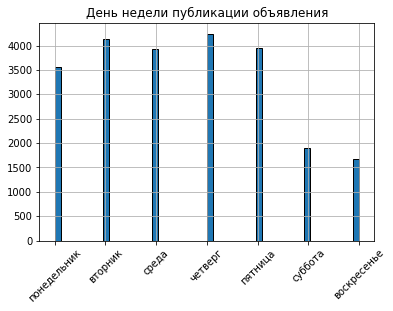

In [64]:
df['weekday_exp'].hist(bins=50, ec='black', figsize=(6,4))
plt.title('День недели публикации объявления')
days = ['понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье']
plt.xticks(ticks=range(7), labels=days, rotation=45)
plt.show()

Вывод: Объявления о продаже недвижимости чаще публикуются в будние дни, в выходные это происходит гораздо реже.

**Столбец month_exp - месяц публикации объявления**

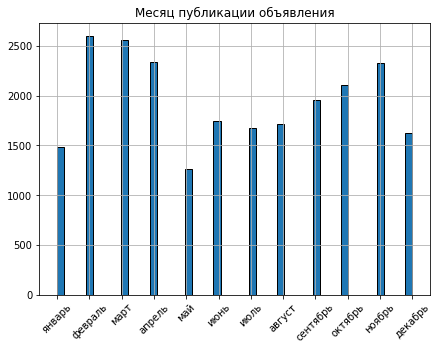

In [65]:
df['month_exp'].hist(bins=50, ec='black', figsize=(7,5))
plt.title('Месяц публикации объявления')
months = [
    'январь', 'февраль', 'март', 'апрель', 'май', 'июнь',
    'июль', 'август', 'сентябрь', 'октябрь', 'ноябрь', 'декабрь'
]
plt.xticks(ticks=range(1, 13), labels=months, rotation=45)
plt.show()

#### Скорость продажи квартир

Изучим, как быстро продавались квартиры (столбец **days_exposition**). Этот параметр показывает, сколько дней «висело» каждое объявление.

Text(0.5, 0, 'дней')

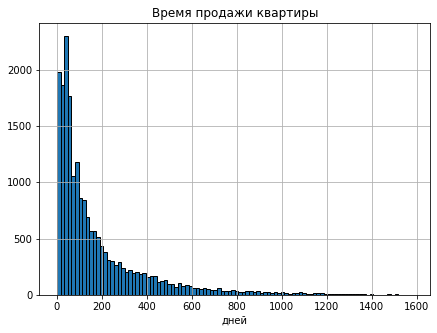

In [66]:
df['days_exposition'].hist(bins=100, figsize=(7,5), ec='black')
plt.title('Время продажи квартиры')
plt.xlabel('дней')

In [67]:
# Изучим описательную статистику

df['days_exposition'].describe()

count   20,270.0
mean       181.0
std        220.0
min          1.0
25%         45.0
50%         95.0
75%        232.0
max      1,580.0
Name: days_exposition, dtype: float64

Стоит проверить выбросы в данных, среднее и медианные значения значительно различаются.

(0.0, 512.5)

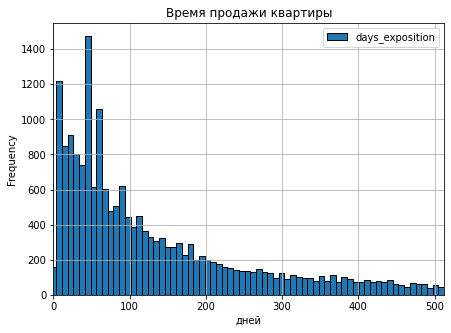

In [68]:
# Построим гистограмму без выбросов

lower, upper = iqr_limits('days_exposition')

df.plot(y='days_exposition', kind='hist', bins=100, range=(lower,upper), figsize=(7,5), ec='black', grid=True)
plt.title('Время продажи квартиры')
plt.xlabel('дней')
plt.xlim(0, upper)

In [69]:
# Значений много, дополнительно проведем подсчет для удобства

df['days_exposition'].value_counts()

45.0       874
60.0       533
7.0        230
30.0       206
90.0       196
          ... 
1.0          1
818.0        1
969.0        1
1,147.0      1
1,174.0      1
Name: days_exposition, Length: 1139, dtype: int64

Вывод: Самый частый временной диапозон продажи квартиры - 45 дней. В целом обычно продажи занимают от 30 до 90 дней. Продажи, которые занимают менее 30 дней можно считать быстрыми, а продажи больше 300 дней необычно долгими.

#### Факторы, которые влияют на стоимость квартиры

Рассмотрим какие факторы больше всего влияют на общую стоимость объекта. Построим графики зависимости цены от следующих параметров:
  - общей площади;
  - жилой площади;
  - площади кухни;
  - количество комнат;
  - типа этажа, на котором расположена квартира (первый, последний, другой);
  - даты размещения (день недели, месяц, год);

**Зависимость цены от площадей**

<AxesSubplot:title={'center':'График зависимости цены от общей и жилой площади, площади кухни'}, xlabel='last_price'>

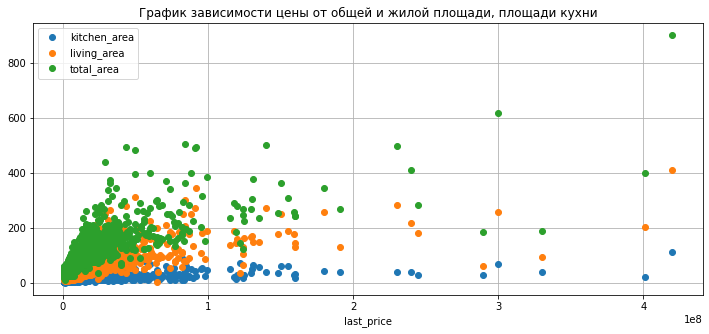

In [70]:
df.pivot_table(
    index='last_price', values=['total_area', 'living_area', 'kitchen_area']).plot(
    style='o', grid=True, figsize=(12, 5), 
    title='График зависимости цены от общей и жилой площади, площади кухни'
)


Чтобы исключить выбросы из построения графика, отфильтруем данные на основе межквартильного размаха.

<AxesSubplot:title={'center':'График зависимости цены от общей и жилой площади, площади кухни (без выбросов)'}, xlabel='last_price'>

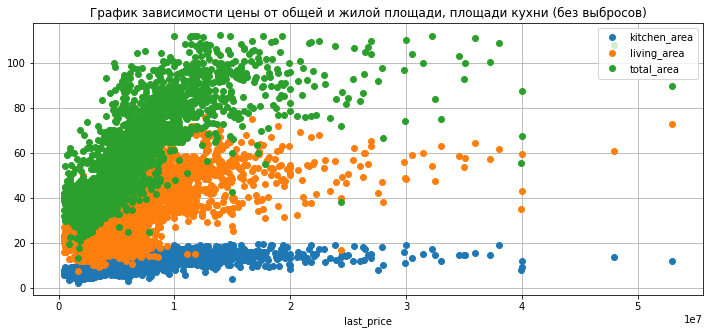

In [71]:
# Функция для фильтрации данных по IQR

def filter_outliers(df, column):
    lower, upper = iqr_limits(column)
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Применим фильтрацию для нужных колонок

filtered_df = df.copy()
columns_to_filter = ['total_area', 'living_area', 'kitchen_area']
for col in columns_to_filter:
    filtered_df = filter_outliers(filtered_df, col)

# Построим график на очищенных данных

filtered_df.pivot_table(
    index='last_price', values=columns_to_filter
).plot(
    style='o', grid=True, figsize=(12, 5),
    title='График зависимости цены от общей и жилой площади, площади кухни (без выбросов)'
)


Посчитаем корреляцию для каждого параметра.

In [72]:
correlation_total = df['total_area'].corr(df['last_price'])
print(f"Корреляция между total_area и last_price: {correlation_total}")

correlation_living = df['living_area'].corr(df['last_price'])
print(f"Корреляция между living_area и last_price: {correlation_living}")

correlation_kitchen = df['kitchen_area'].corr(df['last_price'])
print(f"Корреляция между kitchen_area и last_price: {correlation_kitchen}")

Корреляция между total_area и last_price: 0.7014964484802166
Корреляция между living_area и last_price: 0.6246422775232543
Корреляция между kitchen_area и last_price: 0.546003971343758


**Вывод:**
- Между параметрами total_area и last_price высокая положительная корреляция, на графике также видно, что точки выстраиваются по восходящей линии. Общая площадь объекта недвижимости имеет существенное влияние на его стоимость.
- Между параметрами living_area и last_price умеренная положительная корреляция, на графике видно восходящую линию, но она восходит ниже линии total_area. Это связано с тем, что living_area является лишь частью общей площади, и другие факторы влияют на стоимость недвижимости (наличие балконов и пр.).
- Между параметрами kitchen_area и last_price умеренная положительная корреляция, на графике видно восходящую пологую линию. Площадь кухни также связана со стоимостью квартиры, но её влияние слабее, чем у общей и жилой площади.

**Зависимость цены от количества комнат**

Избавимся от выбросов, чтобы сделать диаграмму понятнее.

Корреляция между rooms и last_price: 0.3530977532726053


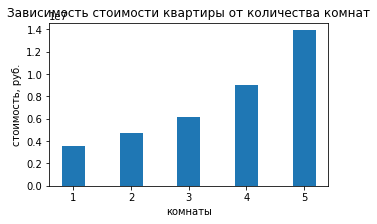

In [73]:
# Рассмотрим значения от 0 до 5, чтобы диаграмма была показательнее

temp_data = df[(df['rooms'] > 0) & (df['rooms'] <= 5)]
pivot_table_rooms = temp_data.pivot_table(index='rooms', values='last_price', aggfunc='median')

plt.figure(figsize=(5,3))
plt.bar(pivot_table_rooms.index, pivot_table_rooms['last_price'], width = 0.4) 
plt.title('Зависимость стоимости квартиры от количества комнат')
plt.xlabel('комнаты')
plt.ylabel('стоимость, руб.');
print('Корреляция между rooms и last_price:', temp_data['last_price'].corr(temp_data['rooms']))

**Вывод:**\
Чем больше комнат в квартире, тем выше ее цена. Между показателями rooms и last_price слабая положительная корреляция.

**Зависимость цены от типа этажа**

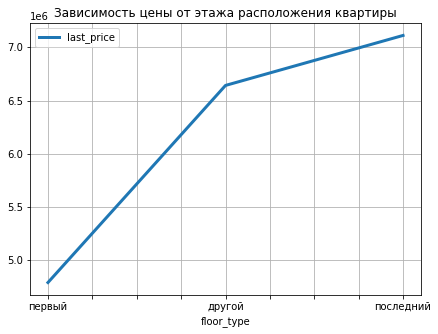

In [74]:
(df
     .pivot_table(index='floor_type', values='last_price').sort_values(by='last_price', ascending=True)
     .plot(grid=True, figsize=(7, 5),linewidth=3, title='Зависимость цены от этажа расположения квартиры')
)
plt.show()

**Вывод:**\
Лучше продаются квартиры на "других" этажах, чем на первом или последнем. Хуже всего продается недвижимость на первых этажах.

**Зависимость цены от даты размещения**

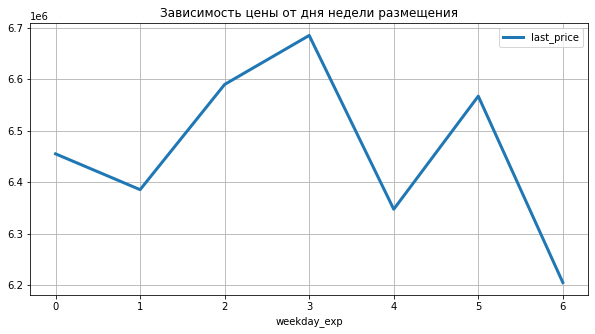

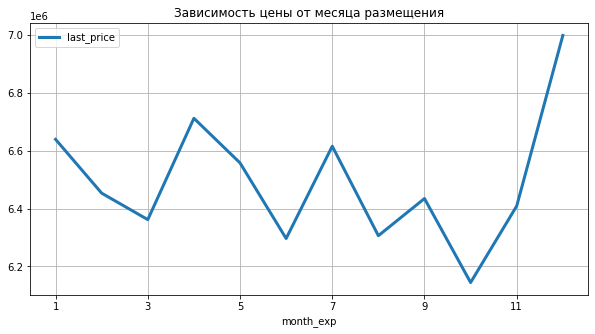

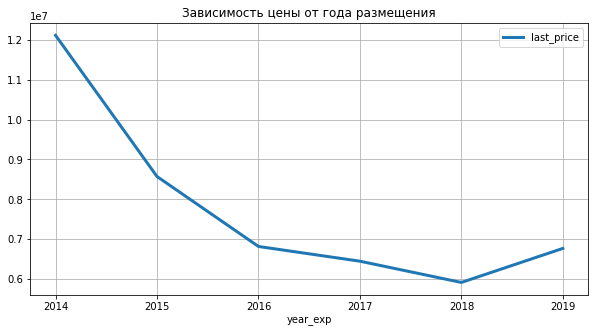

In [75]:
date = {
    'weekday_exp': 'Зависимость цены от дня недели размещения',
    'month_exp': 'Зависимость цены от месяца размещения', 
    'year_exp': 'Зависимость цены от года размещения'
}
for i in date:
    (df
     .pivot_table(index=i, values=['last_price'])
     .plot(grid=True, figsize=(10, 5), linewidth=3, title=date[i]) 
    )

**Вывод**:\
В соответствии с графиками нет зависимости от цены на недвижимость от даты размещения. На графике можно увидеть, что до 2018 года цена на недвижимость падала, а к 2019 начала рости, и эту тенденцию к росту цены мы наблюдаем и сегодня.

#### Средняя цена квадратного метра в населенных пунктах с наибольшим числом объявлений

Посчитаем среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений. Выделим населённые пункты с самой высокой и низкой стоимостью квадратного метра.

In [76]:
top_locality = df.pivot_table(index='locality_name', values='sq_meter_price',
                              aggfunc='count').sort_values(by='sq_meter_price', ascending=False).head(10)
top_locality.columns=['count']
top_locality['mean'] = round(df.pivot_table(index='locality_name',
                                            values='sq_meter_price', aggfunc='mean'),2)
top_locality.sort_values(by='mean', ascending=False)

,count,mean
locality_name,,
Санкт-Петербург,15501,"114,686.9"
Пушкин,369,"103,125.8"
Кудрово,468,"95,522.9"
поселок Парголово,327,"90,175.9"
поселок Мурино,581,"86,077.0"
поселок Шушары,436,"78,830.7"
Колпино,331,"75,328.6"
Всеволожск,390,"68,661.6"
Гатчина,301,"68,634.4"


**Вывод:**
- Наибольшая стоимость недвижимости за квадратный метр в городе Санкт-Петербург - 114686.91.
- Наименьшая стоимость недвижимости за квадратный метр в городе Выборг - 58141.91.

#### Зависимость цены от удаленности от центра города

Text(0, 0.5, 'средняя цена, руб.')

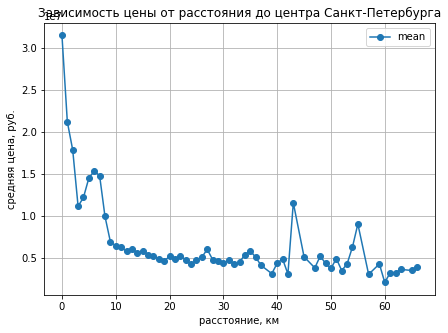

In [77]:
spb_data = df[df['locality_name'] == 'Санкт-Петербург']
spb_data = df.groupby('city_centers_nearest_km')['last_price'].agg(['mean'])
spb_data= spb_data.reset_index()

spb_data.plot(x='city_centers_nearest_km', y='mean', style='-o', figsize=(7, 5), grid=True)
plt.title('Зависимость цены от расстояния до центра Санкт-Петербурга')
plt.xlabel('расстояние, км')
plt.ylabel('средняя цена, руб.')

**Вывод:**
- До 10 км от центра цена стремительно и видимо снижается, затем разница в цене снижается плавнее. 
- Видна зависимость цены от дальности от центра. Чем дальше квартира от центра, тем ниже  на нее цена.

### Общий вывод

**Проведена чистка и обработка первичных данных:**

Приведены к стандартному виду названия столбцов, где возможно (не исказит результаты исследования) заполнены пропуски, проанализированы аномальные значения и обработаны неявные дубликаты (проведена работа с назавниями населенных пунктов - названия стандартизированы).

**Для исследования в таблицу добавлены новые столбцы:**

- Цена одного кв.м.;
- День недели, месяц и год публикации объявления;
- Тип этажа квартиры;
- Расстояние до центра города в км.

**Проведен исследовательский анализ данных:**

Изучены и построены диаграммы для каждого парамтера в исследовании. По результатам иследования наибольшее влияние на стоимость недвижимости оказывают параметры:
- Общая площадь недвижимости (total_area). Анализ показал высокую положительную корреляцию между параметром общей площади и цены: 0.7014964484802166.
- Жилая площадь недвижимости (living_area). Анализ показал высокую положительную корреляцию между параметром жилой площади и цены: 0.6246422775232543.
- Расстояние до центра города (city_centers_nearest_km) - чем дальше квартира от центра, тем меньше ее цена. До 10 км от центра цена стремительно и видимо снижается, затем разница в цене снижается плавнее;
- Этаж расположения квартиры (floor_type) - реже всего покупается недвижимость на первом и последнем этажах, квартиры на промежуточных этажах покупаются чаще;
- Количество комнат в квартире (rooms) - чем больше комнат в квартире, тем выше ее цена.

**По результатам исследования, время продажи квартир:**

- Чаще всего продажа квартиры занимает 45 дней; 
- Обычно продажи занимают от 30 до 90 дней;
- Продажа недвижимости менее чем за 30 дней - необычайно быстрая, а более 300 дней - необычайно долгая.

**Цена квадратного метра в Санкт-Петербурге и Ленинградской области**:

- Средняя цена 1 кв.м. недвижимости в Санкт-Петербурге: 114686.91. Это наибольшая величина из предложенных для изучения цен в населенных пунктах. В центре города цена значительно выше, и снижается по направлению к переферии.
- Самая низкая цена 1 кв.м. недвижимости в Ленинградской области в городе Выборг: 58141.91.